<a href="https://colab.research.google.com/github/IreneAbbey/The-Logistics-Auditor/blob/dev/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Story 1: The Schema Builder**

In [49]:
#Loading all needed files
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

In [50]:
#Average reviews so there's one row per order
reviews_agg = reviews.groupby('order_id').agg({'review_score': 'mean'}).reset_index()

In [51]:
#Joining the three main tables together into one master dataset with inner joins so only rows that actually have matching data on both sides are kept
master_ds = orders.merge(reviews_agg, on='order_id', how='left') \
                  .merge(customers, on='customer_id', how='left')

In [52]:
#Ensure no duplicate rows were introduced by the joins
print("Duplicate rows:", master_ds.duplicated().sum())

Duplicate rows: 0


# **Story 2: The "Real" Delay Calculator**

In [53]:
#Convert columns to actual datetime objects
master_ds['order_estimated_delivery_date'] = pd.to_datetime(master_ds['order_estimated_delivery_date'])
master_ds['order_delivered_customer_date'] = pd.to_datetime(master_ds['order_delivered_customer_date'])

In [54]:
#Calculate the difference in days
master_ds['Days_Difference'] = (
    master_ds['order_estimated_delivery_date'] - master_ds['order_delivered_customer_date']
).dt.days

In [55]:
#Classify each order checking lateness
def classify_with_flags(row):
    status = row['order_status']

    if status in ['canceled', 'unavailable']:
        return "Not Delivered"

    if pd.isna(row['order_delivered_customer_date']):
        return "In Progress / Unknown"

    days = row['Days_Difference']

    if days >= 0:
        return "On Time"
    elif days >= -5:
        return "Late"
    else:
        return "Super Late"

#Apply the classification function to create a new status column
master_ds['Delivery_Status'] = master_ds.apply(classify_with_flags, axis=1)

# **Story 3: The Geographic Heatmap**

In [56]:
#Checking for orders that fall in the late & super late categories
master_ds['is_late'] = master_ds['Delivery_Status'].isin(['Late', 'Super Late'])

In [57]:
#Calculate the average lateness (percentage) for every state
state_analysis = master_ds.groupby('customer_state')['is_late'].mean() * 100

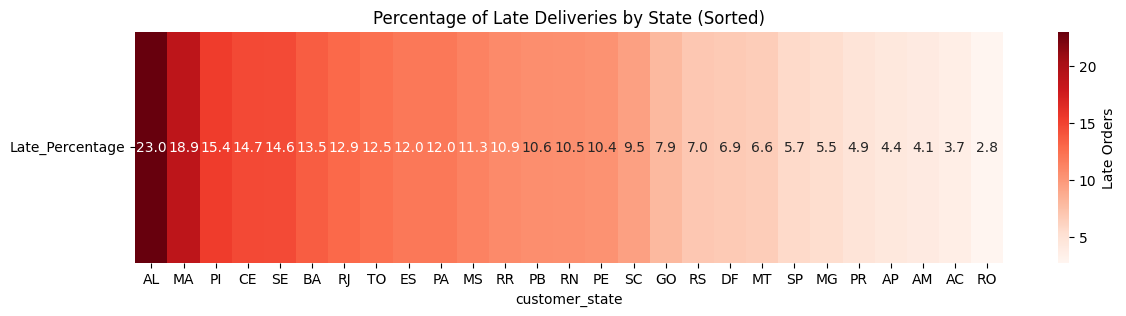

In [58]:
#Sort the states from highest late percentage to lowest to create a heatmap
state_analysis = state_analysis.sort_values(ascending=False)

heatmap_data = state_analysis.to_frame(name="Late_Percentage").T

plt.figure(figsize=(14, 3))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Late Orders"}
)

plt.title("Percentage of Late Deliveries by State (Sorted)")
plt.yticks(rotation=0)
plt.show()

In [59]:
#Define states geographically central/near to the main distribution hubs (São Paulo area)
near_sp_states = ["SP", "RJ", "MG", "ES"]

#Tag states as 'Remote' if they are not in the central list
master_ds["is_remote"] = ~master_ds["customer_state"].isin(near_sp_states)

In [60]:
#Compare the average late delivery rate for Remote vs Near states
remote_vs_near = (
    master_ds
    .groupby("is_remote")["is_late"]
    .mean() * 100
)

print(remote_vs_near)

is_remote
False    7.224680
True     9.283079
Name: is_late, dtype: float64


# **Story 4: The Sentiment Correlation**

In [61]:
#Calculate the average customer review score for each delivery status
sentiment_summary = master_ds.groupby('Delivery_Status')['review_score'].mean()
print(sentiment_summary)

Delivery_Status
In Progress / Unknown    1.817465
Late                     3.461183
Not Delivered            1.666250
On Time                  4.294292
Super Late               1.786587
Name: review_score, dtype: float64


/tmp/ipykernel_844/2840192946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_summary.index, y=sentiment_summary.values, palette="viridis")


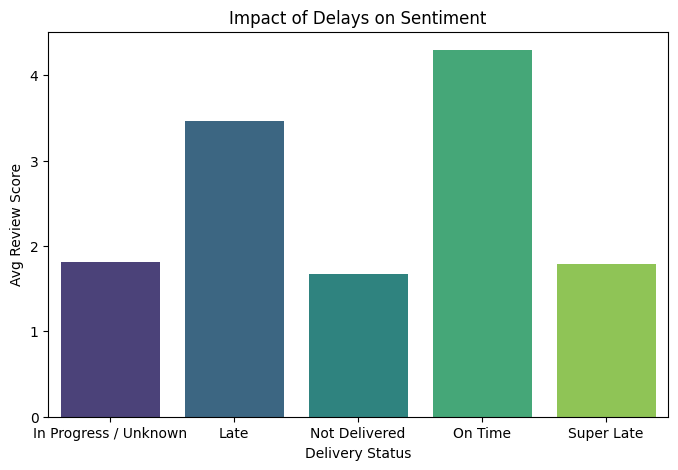

In [62]:
#Plot the relationship between delivery performance and customer ratings
plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_summary.index, y=sentiment_summary.values, palette="viridis")
plt.xlabel("Delivery Status") # Changed from 'Days' to 'Status'
plt.ylabel("Avg Review Score")
plt.title("Impact of Delays on Sentiment")
plt.show()

In [63]:
On_time = sentiment_summary['On Time']
Late = sentiment_summary['Late']

comparison = f"Average On Time Orders Review Score: {On_time: .2f} vs Average Late Orders Review Score:{Late: .2f} "

print(comparison)

Average On Time Orders Review Score:  4.29 vs Average Late Orders Review Score: 3.46 


# **5. Bonus User Story: The "Translation" Challenge**

In [64]:
#Merge the items table to get product IDs for each order
master_ds = master_ds.merge(order_items[['order_id', 'product_id']], on='order_id', how='left')

In [65]:
#Merge the products table to get the original Portuguese category names
master_ds = master_ds.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

In [66]:
#Merge the translation table to get the English equivalents
master_ds = master_ds.merge(translations, on='product_category_name', how='left')

In [67]:
#Check if any categories failed to translate
print(master_ds[master_ds['product_category_name'].notna() & master_ds['product_category_name_english'].isna()]['product_category_name'].unique())

['portateis_cozinha_e_preparadores_de_alimentos' 'pc_gamer']


In [68]:
#Fill missing English names with the original Portuguese name if a translation isn't available
master_ds['product_category_name_english'] = master_ds['product_category_name_english'].fillna(master_ds['product_category_name'])

# **6. The "Candidate's Choice" Challenge**

In [69]:
#Link each order to its corresponding seller
master_ds = master_ds.merge(order_items[['order_id', 'seller_id']], on='order_id', how='left')

In [70]:
#Calculate how many unique orders each seller has handled
seller_counts = order_items.groupby('seller_id')['order_id'].nunique()

In [71]:
#Display statistical distribution of seller volume (helpful to find "High Volume" sellers)
print(seller_counts.describe(percentiles=[.5, .75, .9, .95, .99]))

count    3095.000000
mean       32.313409
std       105.139763
min         1.000000
50%         6.000000
75%        21.500000
90%        69.600000
95%       130.300000
99%       402.240000
max      1854.000000
Name: order_id, dtype: float64


In [72]:
#Calculate the late rate and total order count for every seller & identify the worst "Top Offenders"
seller_stats = master_ds.groupby("seller_id").agg(
    late_rate=('is_late', 'mean'),
    total_orders=('order_id', 'count')
)

seller_stats["late_rate"] *= 100

top_offenders = (
    seller_stats[seller_stats['total_orders'] >= 10]
    .sort_values("late_rate", ascending=False)
)

print(top_offenders.head(10))

                                  late_rate  total_orders
seller_id                                                
8d92f3ea807b89465643c219455e7369  97.368421            38
2709af9587499e95e803a6498a5a56e9  94.255319           470
ec8463980a4e0ea9f8517aea1ed0c419  90.000000            40
8d899e15a5925f097cca50faa49b15e3  85.714286            42
08cdbae123ff67ca4e36d9d641ce0119  83.333333            12
8fec2e460530482132c436cfb5439925  81.818182            11
38e6dada03429a47197d5d584d793b41  73.529412            34
0d83f8e03188682112cc0d93523705cc  72.727273            22
c37b2059d4f90d4feead554e5246565e  69.230769            39
c42fd8e4d47dfb18ce5222f2dd7752f9  68.000000            25


In [73]:
master_ds.to_csv('final_delivery_audit_results.csv', index=False)
print("Audit complete. File saved as 'final_delivery_audit_results.csv'")

Audit complete. File saved as 'final_delivery_audit_results.csv'
